<a href="https://colab.research.google.com/github/emilsar/Cedars/blob/main/Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Load Cedars Data

In [1]:
!git clone https://github.com/emilsar/Cedars.git
%cd Cedars/Project3
! python 1_prepdata.py
from skimage.io import imread
import matplotlib.pyplot as plt
import numpy as np, pandas as pd
from skimage.color import rgb2gray
from skimage.filters import sobel, scharr, apply_hysteresis_threshold, gaussian
from skimage.feature import canny
from skimage.measure import regionprops,regionprops_table
from skimage.morphology import binary_opening, disk, binary_closing, binary_dilation, binary_erosion
from skimage.draw import rectangle_perimeter
from scipy.ndimage import label as scilabel
import cv2
import matplotlib; matplotlib.rcParams['figure.dpi']=300
urothelial_cells=pd.read_pickle("urothelial_cell_toy_data.pkl")
images=np.transpose(urothelial_cells["X"].numpy()*255,(0,2,3,1)).astype(np.uint8)
labels=urothelial_cells["y"]

Cloning into 'Cedars'...
remote: Enumerating objects: 1285, done.
remote: Counting objects: 100% (28/28), done.
remote: Compressing objects: 100% (24/24), done.
remote: Total 1285 (delta 18), reused 4 (delta 4), pack-reused 1257 (from 3)
Receiving objects: 100% (1285/1285), 1.23 GiB | 21.28 MiB/s, done.
Resolving deltas: 100% (498/498), done.
Updating files: 100% (896/896), done.
/content/Cedars/Project3


In [2]:
import numpy as np

def dice_coefficient(pred, target, class_label):
    """
    Calculate Dice coefficient for a specific class.

    Parameters:
    -----------
    pred : np.ndarray
        Predicted segmentation (integer labels)
    target : np.ndarray
        Ground truth segmentation (integer labels)
    class_label : int
        The class to evaluate (0, 1, or 2)

    Returns:
    --------
    dice : float
        Dice coefficient for this class (0 to 1)
    """
    pred_binary = (pred == class_label).astype(float)
    target_binary = (target == class_label).astype(float)

    intersection = np.sum(pred_binary * target_binary)
    sum_pred = np.sum(pred_binary)
    sum_target = np.sum(target_binary)

    # Handle edge case where both pred and target are empty
    if sum_pred == 0 and sum_target == 0:
        return 1.0

    if sum_pred + sum_target == 0:
        return 0.0

    dice = 2 * intersection / (sum_pred + sum_target)
    return dice

def iou_coefficient(pred, target, class_label):
    """
    Calculate Intersection over Union (IoU) for a specific class.

    Parameters:
    -----------
    pred : np.ndarray
        Predicted segmentation (integer labels)
    target : np.ndarray
        Ground truth segmentation (integer labels)
    class_label : int
        The class to evaluate (0, 1, or 2)

    Returns:
    --------
    iou : float
        IoU for this class (0 to 1)
    """
    pred_binary = (pred == class_label).astype(float)
    target_binary = (target == class_label).astype(float)

    intersection = np.sum(pred_binary * target_binary)
    union = np.sum(np.logical_or(pred_binary, target_binary))

    # Handle edge case where union is empty
    if union == 0:
        return 1.0 if intersection == 0 else 0.0

    iou = intersection / union
    return iou

def calculate_all_metrics(pred, target, class_labels=[0, 1, 2]):
    """
    Calculate Dice and IoU for all classes plus mean metrics.

    Returns:
    --------
    metrics : dict
        Dictionary containing per-class and mean metrics
    """
    metrics = {}

    dice_scores = []
    iou_scores = []

    for class_label in class_labels:
        dice = dice_coefficient(pred, target, class_label)
        iou = iou_coefficient(pred, target, class_label)

        class_name = ['Background', 'Cytoplasm', 'Nucleus'][class_label]
        metrics[f'Dice_{class_name}'] = dice
        metrics[f'IoU_{class_name}'] = iou

        dice_scores.append(dice)
        iou_scores.append(iou)

    metrics['Dice_Mean'] = np.mean(dice_scores)
    metrics['IoU_Mean'] = np.mean(iou_scores)

    return metrics

def print_metrics(metrics):
    """Pretty-print metrics table."""
    print("=" * 70)
    print(f"{'Class':<15} {'Dice':<15} {'IoU':<15}")
    print("=" * 70)

    class_names = ['Background', 'Cytoplasm', 'Nucleus']
    for i, class_name in enumerate(class_names):
        dice = metrics[f'Dice_{class_name}']
        iou = metrics[f'IoU_{class_name}']
        print(f"{class_name:<15} {dice:<15.4f} {iou:<15.4f}")

    print("-" * 70)
    print(f"{'Mean':<15} {metrics['Dice_Mean']:<15.4f} {metrics['IoU_Mean']:<15.4f}")
    print("=" * 70)

[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0

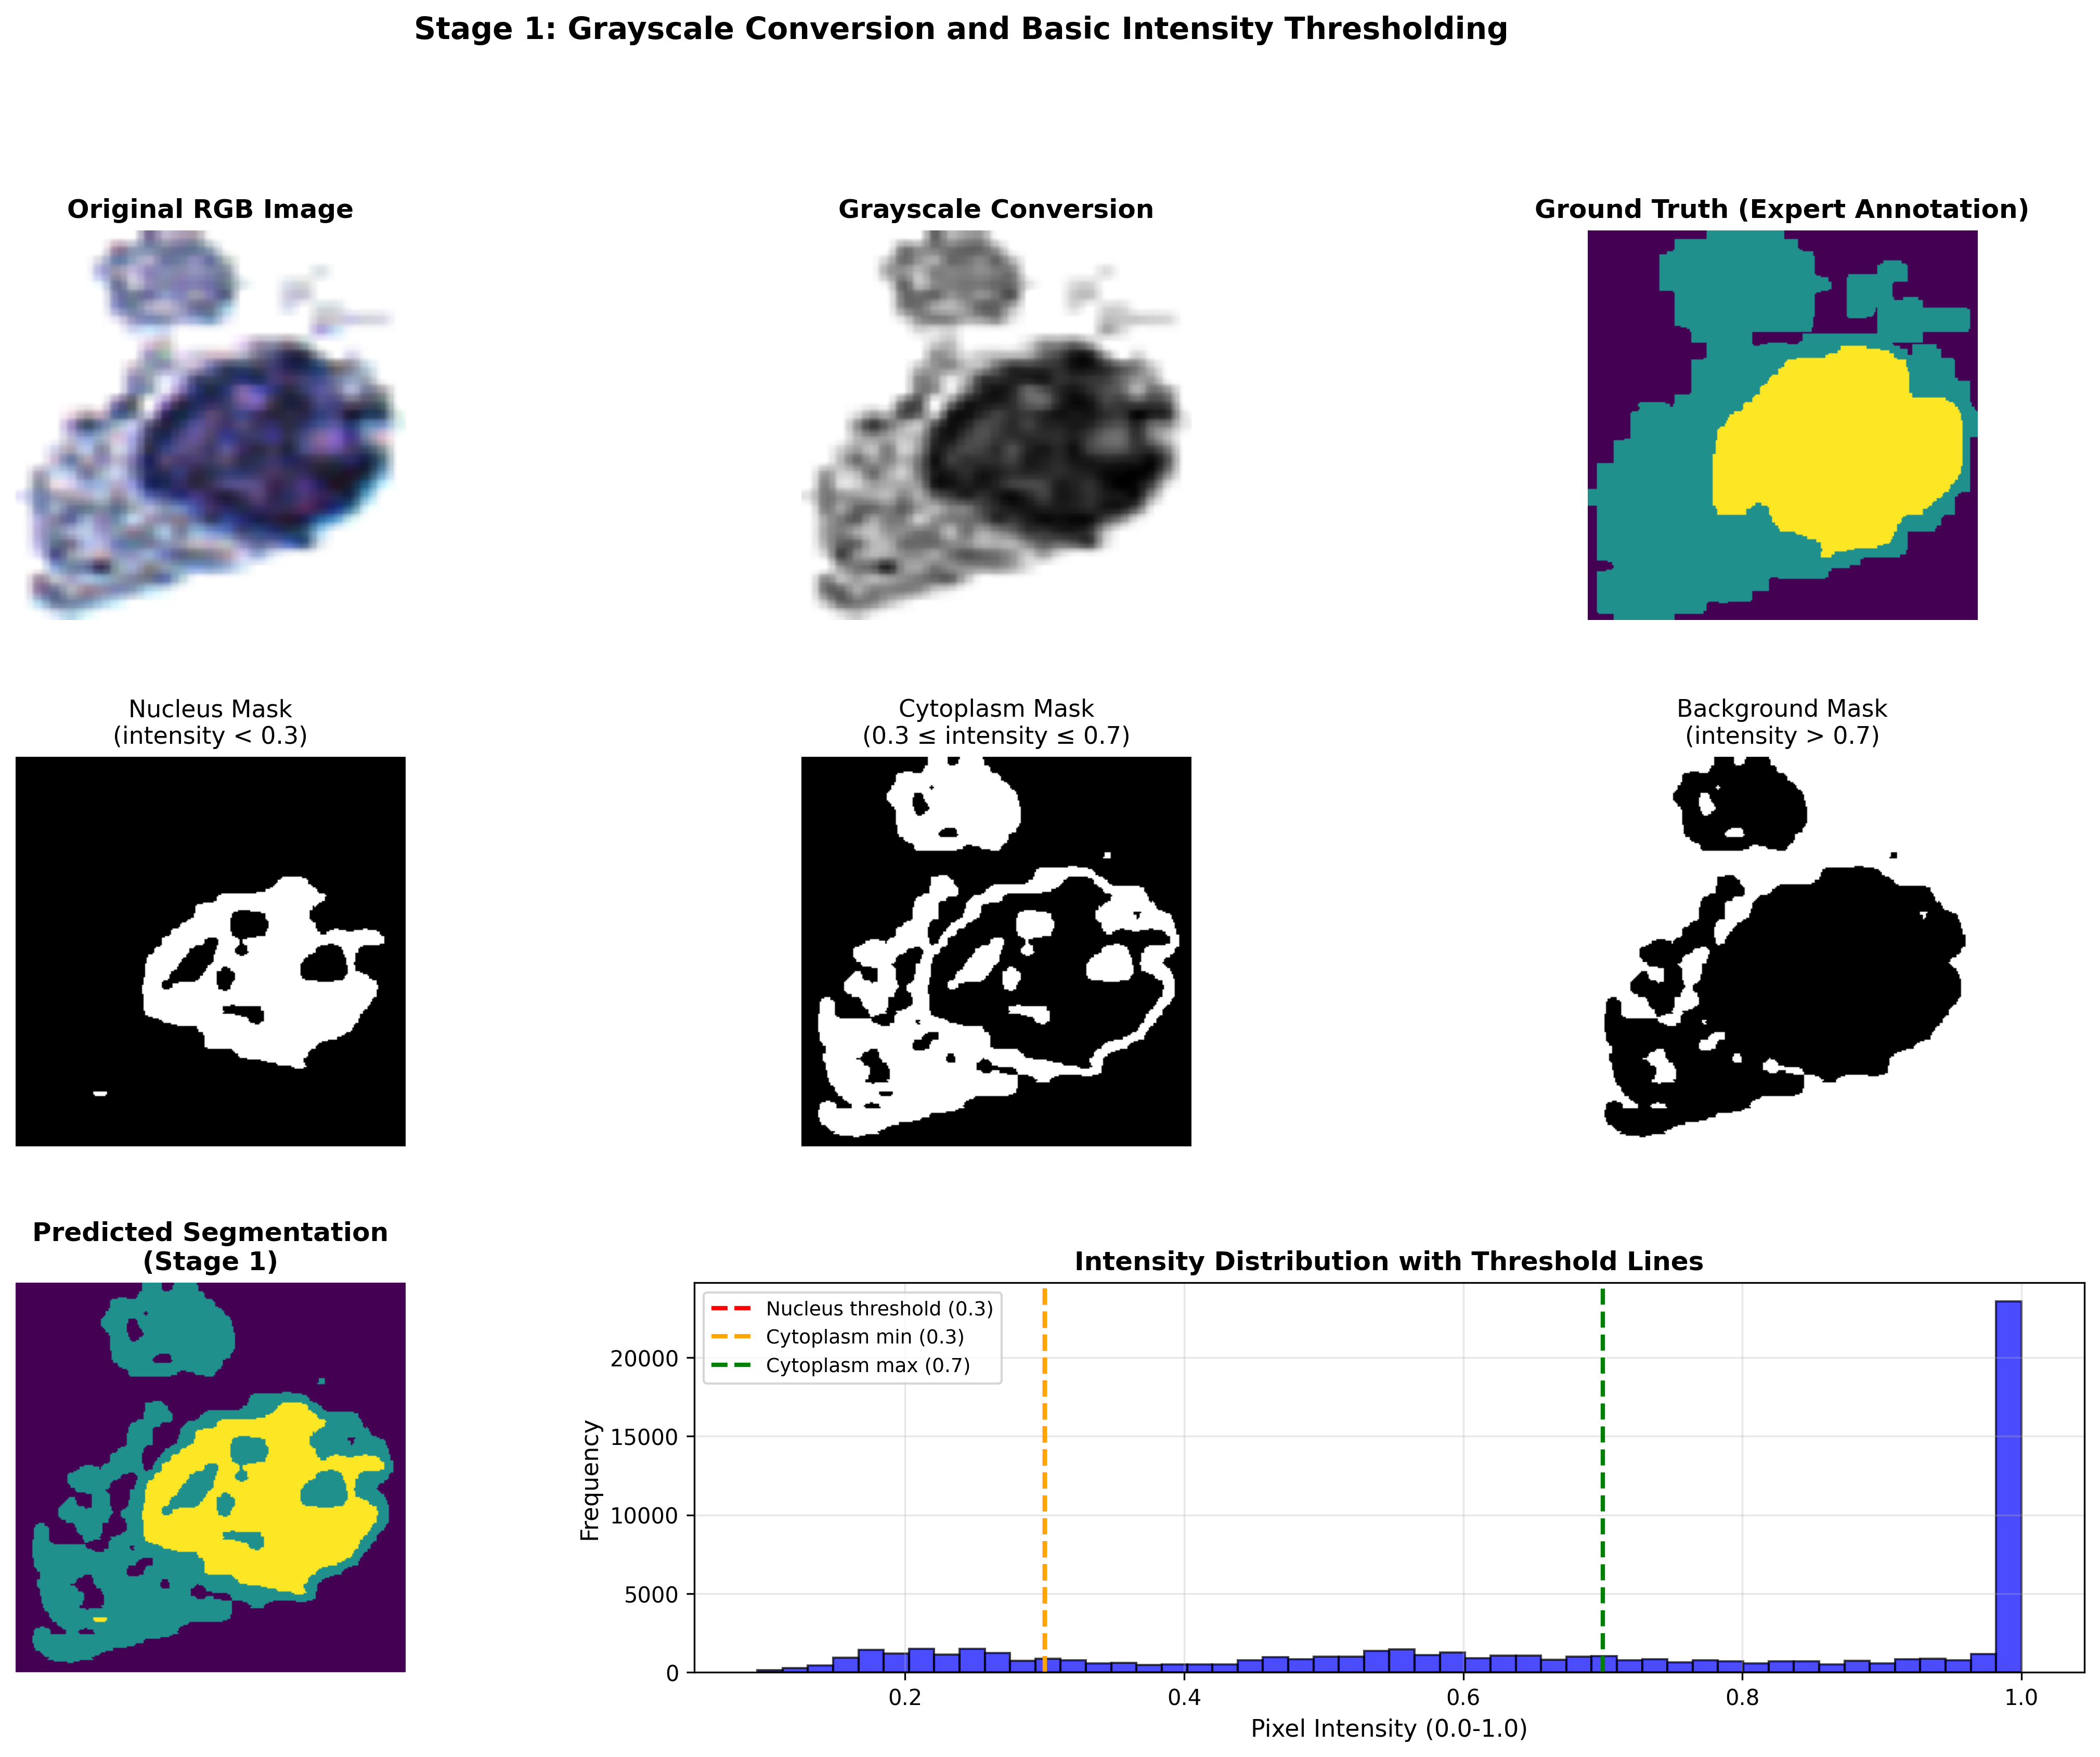


STAGE 1: GRAYSCALE CONVERSION AND BASIC SEGMENTATION
Class           Dice            IoU            
Background      0.7687          0.6243         
Cytoplasm       0.6205          0.4498         
Nucleus         0.8129          0.6848         
----------------------------------------------------------------------
Mean            0.7340          0.5863         

Image Number: 2
Nucleus Threshold: < 0.3
Cytoplasm Threshold: 0.3 to 0.7


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from scipy.ndimage import gaussian_filter
# Set NumPy to print full arrays
np.set_printoptions(threshold=np.inf, linewidth=np.inf)

# ============================================================================
# STAGE 1: GRAYSCALE CONVERSION AND BASIC INTENSITY THRESHOLDING
# ============================================================================

# PARAMETERS (User-adjustable)
image_number = 2
nucleus_max = 0.3      # Intensity threshold for nucleus (dark pixels)
cytoplasm_min = 0.3    # Lower bound for cytoplasm (mid-gray)
cytoplasm_max = 0.7    # Upper bound for cytoplasm

# Get the image
img = images[image_number]
labels_true = labels[image_number]

# STEP 1: Grayscale Conversion
# Using BT.709 standard (modern HDTV): 0.2125*R + 0.7154*G + 0.0721*B
img_uint8 = img.astype(np.uint8)
img_gray = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2GRAY).astype(np.float32) / 255.0

# STEP 2: Intensity-Based Segmentation
nucleus_mask = (img_gray < nucleus_max).astype(int)
cytoplasm_mask = np.logical_and(
    img_gray >= cytoplasm_min,
    img_gray <= cytoplasm_max
).astype(int)
background_mask = (img_gray > cytoplasm_max).astype(int)

# STEP 3: Combine into 3-class segmentation
segmented = np.zeros_like(img_gray, dtype=int)
segmented[nucleus_mask == 1] = 2
segmented[cytoplasm_mask == 1] = 1
segmented[background_mask == 1] = 0


# STEP 4: Calculate Metrics
metrics_stage1 = calculate_all_metrics(segmented, labels_true, class_labels=[0, 1, 2])

# ============================================================================
# VISUALIZATION
# ============================================================================

fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)

# Row 1: Input and Ground Truth
ax1 = fig.add_subplot(gs[0, 0])
ax1.imshow(img)
ax1.set_title("Original RGB Image", fontsize=12, fontweight='bold')
ax1.axis('off')

ax2 = fig.add_subplot(gs[0, 1])
ax2.imshow(img_gray, cmap='gray')
ax2.set_title("Grayscale Conversion", fontsize=12, fontweight='bold')
ax2.axis('off')

ax3 = fig.add_subplot(gs[0, 2])
ax3.imshow(labels_true, cmap='viridis', vmin=0, vmax=2)
ax3.set_title("Ground Truth (Expert Annotation)", fontsize=12, fontweight='bold')
ax3.axis('off')

# Row 2: Segmentation Masks
ax4 = fig.add_subplot(gs[1, 0])
ax4.imshow(nucleus_mask, cmap='gray')
ax4.set_title("Nucleus Mask\n(intensity < 0.3)", fontsize=11)
ax4.axis('off')

ax5 = fig.add_subplot(gs[1, 1])
ax5.imshow(cytoplasm_mask, cmap='gray')
ax5.set_title("Cytoplasm Mask\n(0.3 ≤ intensity ≤ 0.7)", fontsize=11)
ax5.axis('off')

ax6 = fig.add_subplot(gs[1, 2])
ax6.imshow(background_mask, cmap='gray')
ax6.set_title("Background Mask\n(intensity > 0.7)", fontsize=11)
ax6.axis('off')

# Row 3: Segmentation and Histogram
ax7 = fig.add_subplot(gs[2, 0])
ax7.imshow(segmented, cmap='viridis', vmin=0, vmax=2)
ax7.set_title("Predicted Segmentation\n(Stage 1)", fontsize=12, fontweight='bold')
ax7.axis('off')

# Intensity Histogram with thresholds
ax8 = fig.add_subplot(gs[2, 1:])
ax8.hist(img_gray.flatten(), bins=50, alpha=0.7, color='blue', edgecolor='black')
ax8.axvline(nucleus_max, color='red', linestyle='--', linewidth=2, label=f'Nucleus threshold ({nucleus_max})')
ax8.axvline(cytoplasm_min, color='orange', linestyle='--', linewidth=2, label=f'Cytoplasm min ({cytoplasm_min})')
ax8.axvline(cytoplasm_max, color='green', linestyle='--', linewidth=2, label=f'Cytoplasm max ({cytoplasm_max})')
ax8.set_xlabel('Pixel Intensity (0.0-1.0)', fontsize=11)
ax8.set_ylabel('Frequency', fontsize=11)
ax8.set_title("Intensity Distribution with Threshold Lines", fontsize=12, fontweight='bold')
ax8.legend(fontsize=9)
ax8.grid(alpha=0.3)

plt.suptitle('Stage 1: Grayscale Conversion and Basic Intensity Thresholding',
             fontsize=14, fontweight='bold', y=0.995)
plt.show()

# Print metrics
print("\n" + "="*70)
print("STAGE 1: GRAYSCALE CONVERSION AND BASIC SEGMENTATION")
print("="*70)
print_metrics(metrics_stage1)

print(f"\nImage Number: {image_number}")
print(f"Nucleus Threshold: < {nucleus_max}")
print(f"Cytoplasm Threshold: {cytoplasm_min} to {cytoplasm_max}")